In [30]:
import sys
import os
import numpy as np
import time
import warnings
warnings.filterwarnings("ignore")

from collections import defaultdict, deque # deque is nodig voor histwrapper
from gymnasium import spaces, Wrapper # Wrapper is de basisklasse voor custom wrappers
import matplotlib.pyplot as plt
import gymnasium as gym


sys.path.append(os.path.expanduser("~/src/swingup/q_learning"))
from UnbalancedDiskDiscrete_latest_oldy import UnbalancedDisk

In [31]:
class UnbalancedDiskResetWrapper(gym.Wrapper):
    """
    Wrapper om de reset methode van de omgeving te normaliseren
    voor compatibiliteit met verschillende Gymnasium versies.
    """
    def __init__(self, env): super().__init__(env)
    def reset(self, *, seed=None, options=None):
        try: obs, info = self.env.reset(seed=seed)
        except TypeError: obs, info = self.env.reset();
        return obs, info

class Discretize_obs(gym.Wrapper):
    """
    Wrapper om de continue observatieruimte te discretiseren naar MultiDiscrete.
    Dit is essentieel voor traditionele Q-learning, die discrete staten vereist.
    """
    def __init__(self, env, nvec):
        super(Discretize_obs, self).__init__(env)

        original_obs_space = env.observation_space
        
        # --- Initialisatie van self.nvec_array en de nieuwe observation_space ---
        if isinstance(original_obs_space, spaces.Box):
            # Als de originele ruimte een Box (continu) is, dan gebruiken we de shape.
            original_obs_shape = original_obs_space.shape
            self.olow = original_obs_space.low
            self.ohigh = original_obs_space.high
        elif isinstance(original_obs_space, spaces.MultiDiscrete):
            # Als de originele ruimte al MultiDiscrete is, dan is de 'shape' de lengte van nvec.
            original_obs_shape = original_obs_space.nvec.shape
            self.olow = np.zeros_like(original_obs_space.nvec, dtype=np.float32)
            self.ohigh = (original_obs_space.nvec - 1).astype(np.float32)
        else:
            raise TypeError(f"Onondersteund observatieruimte type van onderliggende omgeving: {type(original_obs_space)}. Verwacht Box of MultiDiscrete.")

        if isinstance(nvec, int):
            # Als nvec een enkel getal is, vul dan een NumPy array met die waarde,
            # met de juiste vorm van de observatie.
            self.nvec_array = np.full(original_obs_shape, nvec, dtype=int)
        else:
            # Als nvec al een array/lijst is, zorg dan dat het de juiste vorm heeft.
            self.nvec_array = np.array(nvec, dtype=int)
            if self.nvec_array.shape != original_obs_shape:
                raise ValueError(f"De meegeleverde nvec shape {self.nvec_array.shape} komt niet overeen "
                                 f"met de observatieruimte shape {original_obs_shape}")
        
        self.observation_space = gym.spaces.MultiDiscrete(self.nvec_array.flatten())
        self.range_obs = self.ohigh - self.olow
        self.range_obs[self.range_obs == 0] = 1.0 # Vervang nullen door 1.0

    def discretize(self, observation):
        """
        Converteert een continue observatie naar een discrete tuple.
        """
        observation = np.clip(observation, self.olow, self.ohigh)
        discrete_obs_float = ((observation - self.olow) / self.range_obs * self.nvec_array)
        return tuple(np.clip(discrete_obs_float, 0, self.nvec_array - 1).astype(int).flatten())
        
    def step(self, action):
        observation, reward, terminated, truncated, info = self.env.step(action)
        return self.discretize(observation), reward, terminated, truncated, info

    def reset(self):
        obs, info = self.env.reset()
        obs_dis = self.discretize(obs)
        return obs_dis, info


def roll_mean(ar,start=2000,N=50): #smoothing if needed
    """
    Berekent een exponentieel voortschrijdend gemiddelde.
    `start` is de initiële waarde voor het gemiddelde.
    `N` bepaalt de gladheid (hoe groter N, hoe gladder).
    """
    s = 1-1/N
    k = start
    out = np.zeros(ar.shape)
    for i,a in enumerate(ar):
        k = s*k + (1-s)*a
    return out

def argmax(a):
    """
    Retourneert een willekeurige index van de maximale waarde in een array.
    Dit voorkomt een bias bij meerdere gelijke maximale waarden (tie-breaking).
    """
    a = np.array(a)
    return np.random.choice(np.arange(len(a),dtype=int)[a==np.max(a)])




In [32]:
def Qlearn(env, nsteps=5000, nvec_angle = 360 , nvec_rps = 30 ,callbackfeq=5000, alpha=0.05, gamma=0.98, checkpoint_name='best_Qmat.pkl', callback=None):
    import pickle
    Qmat = defaultdict(float)
    env_time = env

    while not isinstance(env_time,gym.wrappers.TimeLimit):
        if hasattr(env_time, 'env'):
            env_time = env_time.env
        else:
            print("Waarschuwing: Kan geen gym.wrappers.TimeLimit vinden in de omgeving. _elapsed_steps is mogelijk niet beschikbaar.")
            break
            
    ep_lengths = []
    ep_lengths_steps = []
    ep_rewards = []
    obs, info = env.reset()
    current_episode_reward = 0.0
    best_avg_reward = -float('inf')
    best_Qmat_to_save = None

    if os.path.exists(checkpoint_name):
        try:
            with open(checkpoint_name, 'rb') as f:
                Qmat_loaded_at_start = pickle.load(f)
                Qmat.update(Qmat_loaded_at_start)
            print(f"Succesvol initiële Qmat geladen van {checkpoint_name}. Training wordt voortgezet.")
        except Exception as e:
            print(f"Waarschuwing: Kon initiële Qmat niet laden van {checkpoint_name}: {e}. Starten met een lege Qmat.")
    else:
        print(f"Geen initieel checkpoint gevonden op {checkpoint_name}. Starten met een lege Qmat.")
            
    for z in range(nsteps):
        # eps = 0.6 - 0.55 * z / (nsteps - 1)

        # eps = max(0.05,
        #         1 - 0.95 * z / (nvec_angle * nvec_rps * 3 - 1),
        #         0.3 - 0.25 * z * 1.4 / (nsteps - 1))

        # eps = max(
        #     0.05,  # Minimum threshold for eps
        #     1 - 0.99 * z / (nvec_angle * nvec_rps * 2.5 - 1),         # First decay function
        #     0.3 - 0.15 * z * 1.4 / (nsteps - 1) ,                     # Second decay function
        #     0.4 - 0.15 * z *3/ (nsteps - 1)
        # )
        eps = max(
            0.02,  # Minimum threshold for eps
            # 
            # exponentiële decay functie die snel begint en langzaam afneemt, met een asymptoot bij 0.05
            0.7 * np.exp(-5 * z / nsteps) + 0.02
        )

        if np.random.uniform()<eps:
            action = env.action_space.sample()
        else:
            action = argmax([Qmat[(obs, i)] for i in range(env.action_space.n)])
            
        obs_new, reward, terminated, truncated, info = env.step(action)
        current_episode_reward += reward

        if callback and z % callbackfeq == 0:
            callback(Qmat, z, env)

        if terminated or truncated:
            A = reward - Qmat[(obs, action)]
            Qmat[(obs, action)] += alpha * A
            
            print_status_message = ""
            if terminated:
                print_status_message = f"{env_time._elapsed_steps}, stap {z+1}. Totale Beloning: {current_episode_reward:.2f}"
            elif truncated:
                print_status_message = f"{env_time._elapsed_steps}, stap {z+1}. Totale Beloning: {current_episode_reward:.2f}"
            
            
            ep_lengths.append(env_time._elapsed_steps)
            ep_lengths_steps.append(z)
            ep_rewards.append(current_episode_reward)
            obs, info = env.reset()
            if current_episode_reward > best_avg_reward:
                best_avg_reward = current_episode_reward
                best_Qmat_to_save = Qmat.copy()
                
                try:
                    with open(checkpoint_name, 'wb') as f:
                        pickle.dump(best_Qmat_to_save, f)
                    print(f"################################# \n NIEUWE BESTE GEMIDDELDE BELONING: {current_episode_reward}, Qmat opgeslagen naar {checkpoint_name}... \n#################################")
                except Exception as e:
                    print(f"Fout bij opslaan Qmat: {e}")

                    
            current_episode_reward = 0.0
            print(print_status_message)

        else:
            A = reward + gamma * max(Qmat[(obs_new, action_next)] for action_next in range(env.action_space.n)) - Qmat[(obs, action)]
            Qmat[(obs, action)] += alpha * A
            obs = obs_new

    if os.path.exists(checkpoint_name):
        try:
            with open(checkpoint_name, 'rb') as f:
                Qmat_final = pickle.load(f)
            print(f"Laden van de uiteindelijke beste Qmat (gemiddelde beloning: {best_avg_reward:.2f}) van {checkpoint_name}")
            return Qmat_final, np.array(ep_lengths_steps), np.array(ep_lengths), np.array(ep_rewards)
        except Exception as e:
            print(f"Fout bij laden van de uiteindelijke beste Qmat van {checkpoint_name}: {e}. Huidige Qmat wordt geretourneerd.")
    elif best_Qmat_to_save is not None:
        print("Geen checkpointbestand gevonden, maar best_Qmat_to_save was ingesteld. Deze wordt geretourneerd.")
        return best_Qmat_to_save, np.array(ep_lengths_steps), np.array(ep_lengths), np.array(ep_rewards)
    else:
        print("Geen beste Qmat is opgeslagen tijdens training (mogelijk niet genoeg episodes of geen verbetering). Huidige Qmat wordt geretourneerd.")

    return Qmat, np.array(ep_lengths_steps), np.array(ep_lengths), np.array(ep_rewards)


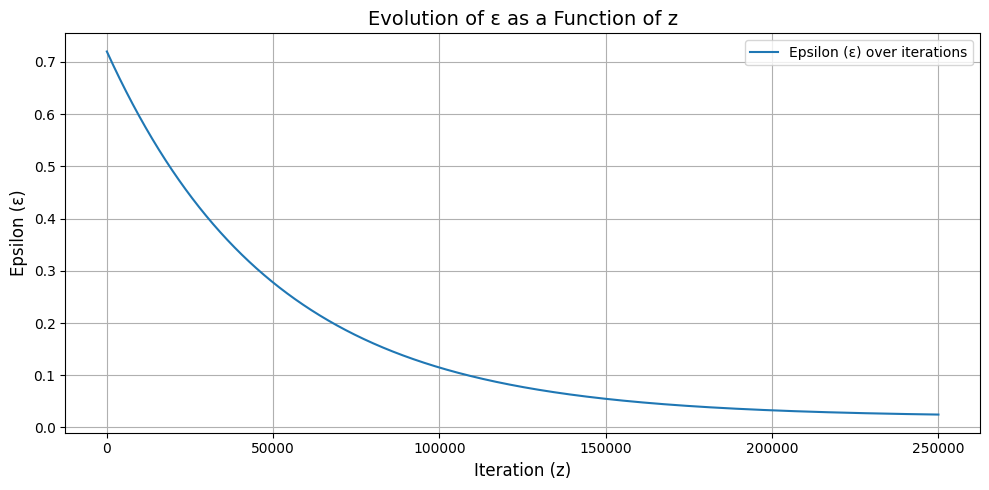

In [33]:
import matplotlib.pyplot as plt

# Define parameters
n_steps = 250_000                # Total number of steps (samples)
n_vec_angle = 360                  # Number of angular divisions
n_vec_rps = 30                     # Rotations per second

# Create the z-axis values
z_values = range(n_steps)

# Compute epsilon values with piecewise decay logic
# eps_values = [
#     max(
#         0.05,  # Minimum threshold for eps
#         1 - 0.99 * z / (n_vec_angle * n_vec_rps * 2.5 - 1),         # First decay function
#         0.3 - 0.15 * z * 1.4 / (n_steps - 1) ,                     # Second decay function
#         0.4 - 0.15 * z *3/ (n_steps - 1)
#     )
#     for z in z_values
# ]


eps_values = [
    max(
        0.02,  # Minimum threshold for eps
        # exponentiële decay functie die snel begint en langzaam afneemt, met een asymptoot bij 0.05
        # 0.3 * np.exp(-5 * z / n_steps) + 0.05
        0.7 * np.exp(-5 * z / (n_steps)) + 0.02
    )
    for z in z_values
]


# eps_values = [
#     max(0.05,
#                 1 - 0.95 * z / (n_vec_angle * n_vec_rps * 3 - 1),
#                 0.3 - 0.25 * z * 1.4 / (n_vec_rps - 1))
#     for z in z_values
# ]

# Plot the evolution of epsilon over z
plt.figure(figsize=(10, 5))
plt.plot(z_values, eps_values, label="Epsilon (ε) over iterations")
plt.xlabel("Iteration (z)", fontsize=12)
plt.ylabel("Epsilon (ε)", fontsize=12)
plt.title("Evolution of ε as a Function of z", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
# --- Hoofddeel van het Script: Training en Evaluatie ---

checkpoint_filename = 'Q_learning_2_neww_reward_v16.pkl' # De bestandsnaam voor jouw opgeslagen Q-tabel

# --- Trainingsfase ---
print("\n--- START TRAINING ---")
nvec_angle = 360
nvec_rps = 50
max_episode_steps_train = 300
Qmats = {}
for nvec in [20]:
    env_train = UnbalancedDisk(dt=0.025, umax=3., render_mode=None)
    env_train = UnbalancedDiskResetWrapper(env_train)
    env_train = gym.wrappers.TimeLimit(env_train, max_episode_steps=max_episode_steps_train)
    env_train = Discretize_obs(env_train, nvec=[nvec_angle,nvec_rps])

    print(f'nvec={nvec}')
    Qmat_trained, ep_lengths_steps, ep_lengths, ep_rewards = Qlearn(
        env_train,
        nsteps=350_000, # Aantal trainingsstappen
        nvec_angle = nvec_angle,
        nvec_rps = nvec_rps,
        callbackfeq=5000, # Frequentie voor evaluatie en potentieel opslaan
        checkpoint_name=checkpoint_filename # De gedefinieerde bestandsnaam
    )
    Qmats[nvec] = Qmat_trained
    env_train.close()

if os.path.exists(checkpoint_filename):
    print(f"\nCheck: Checkpoint file '{checkpoint_filename}' found on disk.")
    try:
        import pickle
        with open(checkpoint_filename, 'rb') as f:
            loaded_Qmat_final_check = pickle.load(f)
        print(f"Successfully loaded Qmat from '{checkpoint_filename}' for final check. Size: {len(loaded_Qmat_final_check)} entries.")
    except Exception as e:
        print(f"Error loading saved Qmat for final check: {e}")
else:
    print(f"\nCheck: Checkpoint file '{checkpoint_filename}' NOT found on disk.")





--- START TRAINING ---
nvec=20
Succesvol initiële Qmat geladen van Q_learning_2_neww_reward_v15.pkl. Training wordt voortgezet.
################################# 
 NIEUWE BESTE GEMIDDELDE BELONING: -130.65440707437665, Qmat opgeslagen naar Q_learning_2_neww_reward_v15.pkl... 
#################################
300, stap 300. Totale Beloning: -130.65
################################# 
 NIEUWE BESTE GEMIDDELDE BELONING: -123.73540879545304, Qmat opgeslagen naar Q_learning_2_neww_reward_v15.pkl... 
#################################
300, stap 600. Totale Beloning: -123.74
################################# 
 NIEUWE BESTE GEMIDDELDE BELONING: -105.5307754371901, Qmat opgeslagen naar Q_learning_2_neww_reward_v15.pkl... 
#################################
300, stap 900. Totale Beloning: -105.53
################################# 
 NIEUWE BESTE GEMIDDELDE BELONING: -46.546189608885314, Qmat opgeslagen naar Q_learning_2_neww_reward_v15.pkl... 
#################################
300, stap 1200. Tota

Laatste 10 episode beloningen: [-50.06035649 476.12058189 433.08603519 665.52883646 527.22205831
 451.63832764 463.16130031 373.51743898 667.39377701 465.71125956]


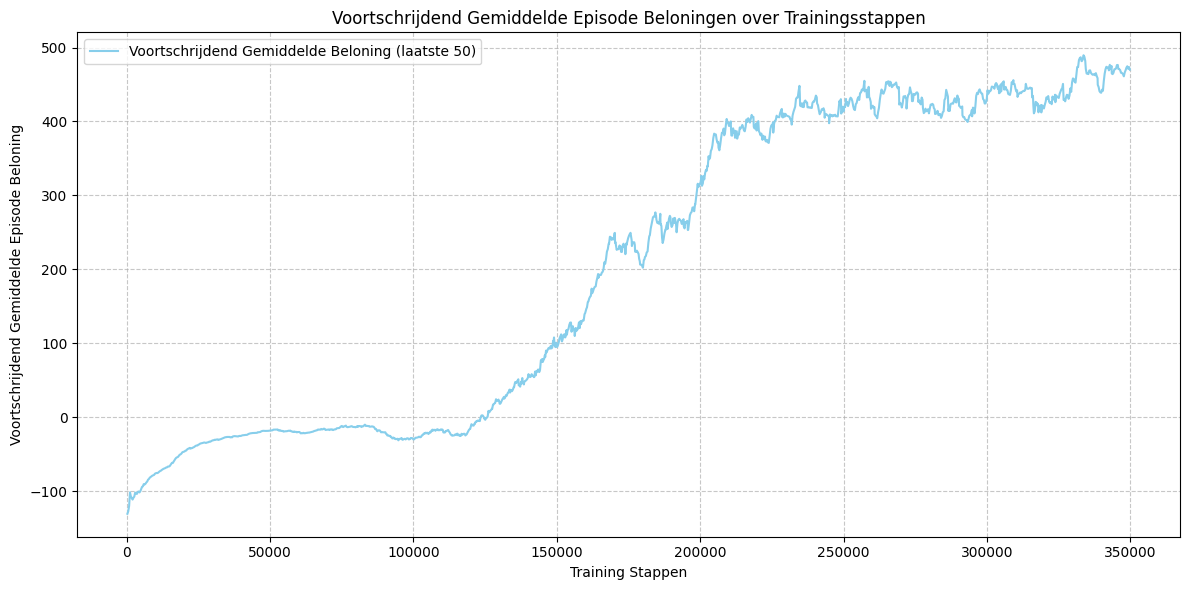

In [35]:
from matplotlib import pyplot as plt
import numpy as np
print(f"Laatste 10 episode beloningen: {ep_rewards[-10:]}")
N_ROLLING_MEAN = 50 # Je kunt dit aanpassen naar behoefte
rolled_rewards = []
for i in range(len(ep_rewards)):
    start_index = max(0, i - N_ROLLING_MEAN + 1)
    rolled_rewards.append(np.mean(ep_rewards[start_index:i+1]))

plt.figure(figsize=(12, 6)) # Optioneel: Maak de plot wat groter
plt.plot(ep_lengths_steps, rolled_rewards, label=f'Voortschrijdend Gemiddelde Beloning (laatste {N_ROLLING_MEAN})', color='skyblue')
plt.legend()
plt.xlabel("Training Stappen")
plt.ylabel("Voortschrijdend Gemiddelde Episode Beloning")
plt.title("Voortschrijdend Gemiddelde Episode Beloningen over Trainingsstappen")
plt.grid(True, linestyle='--', alpha=0.7) # Voeg een subtiel raster toe
plt.tight_layout() # Zorgt ervoor dat alle elementen goed passen
plt.show()

In [ ]:
# --- Evaluatie Fase: Runnen met het beste Model ---
print("\n--- START EVALUATION WITH BEST MODEL ---")
checkpoint_filename = 'Q_learning_2_neww_reward_v16.pkl' 
best_Qmat = None
nvec_angle = 360
nvec_rps = 50
if os.path.exists(checkpoint_filename):
    try:
        import pickle
        with open(checkpoint_filename, 'rb') as f:
            best_Qmat = pickle.load(f)
        print(f"Successfully loaded the best Qmat model from '{checkpoint_filename}'.")
    except Exception as e:
        print(f"Error loading the best Qmat model: {e}. Cannot evaluate.")
else:
    print(f"Error: Checkpoint file '{checkpoint_filename}' not found. Please ensure training completed successfully.")
    
eval_max_episode_steps = 300 # Must match what was used during training
if best_Qmat is not None:
    
    env_eval = UnbalancedDisk(dt=0.025, umax=3. , render_mode='human')
    env_eval = UnbalancedDiskResetWrapper(env_eval)
    env_eval = gym.wrappers.TimeLimit(env_eval, max_episode_steps=eval_max_episode_steps)
    env_eval = Discretize_obs(env_eval, nvec=[nvec_angle,nvec_rps])

    num_eval_episodes = 5
    eval_rewards = []
    eval_lengths = []

    print(f"Starting evaluation of {num_eval_episodes} episodes with the best model (no exploration)...")
    for i in range(num_eval_episodes):
        obs, info = env_eval.reset()
        episode_reward = 0
        done = False
        step_count = 0

        while not done:
            action = argmax([best_Qmat[(obs, a)] for a in range(env_eval.action_space.n)])
            
            obs_new, reward, terminated, truncated, info = env_eval.step(action)
            episode_reward += reward
            step_count += 1
            done = terminated or truncated

            obs = obs_new
            
            env_eval.render()
            time.sleep(1/30)

        eval_rewards.append(episode_reward)
        eval_lengths.append(step_count)
        print(f"Evaluation Episode {i+1}: Length={step_count}, Reward={episode_reward:.2f}")

    avg_eval_reward = np.mean(eval_rewards)
    avg_eval_length = np.mean(eval_lengths)
    print(f"\n--- EVALUATION RESULTS ---")
    print(f"Average reward over {num_eval_episodes} evaluation episodes: {avg_eval_reward:.2f}")
    print(f"Average episode length over {num_eval_episodes} evaluation episodes: {avg_eval_length:.2f}")

    env_eval.close()
else:
    print("No best Qmat available for evaluation. Ensure the checkpoint file exists.")
# --- Einde van het Script ---


--- START EVALUATION WITH BEST MODEL ---
Successfully loaded the best Qmat model from 'Q_learning_2_neww_reward_v15.pkl'.
Starting evaluation of 5 episodes with the best model (no exploration)...
Evaluation Episode 1: Length=300, Reward=462.84
Evaluation Episode 2: Length=300, Reward=572.60
Evaluation Episode 3: Length=300, Reward=472.46
Evaluation Episode 4: Length=300, Reward=474.01
Evaluation Episode 5: Length=300, Reward=714.23

--- EVALUATION RESULTS ---
Average reward over 5 evaluation episodes: 539.23
Average episode length over 5 evaluation episodes: 300.00
